<a href="https://colab.research.google.com/github/Zheleikina/ML/blob/main/%D0%9B%D0%A02_2_%D0%96%D0%B5%D0%BB%D0%B5%D0%B9%D0%BA%D1%96%D0%BD%D0%B0_3_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Желейкіна Аліна, ФІТ 3-9

**Була присутня на парі**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [51]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("mahmoudshogaa/titanic-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


In [5]:
df = pd.read_csv(os.path.join(path, "titanic.csv"))

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


**About Dataset**

The dataset typically includes the following columns:

**PassengerId:** A unique identifier for each passenger.
Survived: This column indicates whether a passenger survived (1) or did not survive (0).

**Pclass (Ticket class):** A proxy for socio-economic status, with 1 being the highest class and 3 the lowest.

**Name:** The name of the passenger.

**Sex:** The gender of the passenger.

**Age:** The age of the passenger. (Note: There might be missing values in this column.)

**SibSp:** The number of siblings or spouses the passenger had aboard the Titanic.

**Parch:** текст жирним шрифтом The number of parents or children the passenger had aboard the Titanic.

**Ticket:** The ticket number.

**Fare:** The amount of money the passenger paid for the ticket.

The main goal of using this dataset is to predict whether a passenger survived or not based on various features. It serves as a popular introductory dataset for those learning data analysis, machine learning, and predictive modeling. Keep in mind that the dataset may be subject to variations and updates, so it's always a good idea to check the Kaggle website or dataset documentation for the most recent information.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [11]:
df['Age'] = df['Age'].fillna(df['Age'].median(skipna=True))

# Видаляємо колонки
df.drop(['Cabin', 'Embarked'], axis=1, errors='ignore', inplace=True)

In [10]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [12]:
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


In [13]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


Змінили бінарні ознаки на 0 і 1

In [14]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

print(f'Data types of the dataset:\n{df.dtypes}')

Data types of the dataset:
Survived      int64
Pclass        int64
Sex           int64
Age         float64
Fare        float64
dtype: object


/tmp/ipykernel_1205/275882515.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})


In [15]:
df.describe()

,Survived,Pclass,Sex,Age,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.361582,32.204208
std,0.486592,0.836071,0.477990,13.019697,49.693429
min,0.000000,1.000000,0.000000,0.420000,0.000000
25%,0.000000,2.000000,0.000000,22.000000,7.910400
50%,0.000000,3.000000,0.000000,28.000000,14.454200
75%,1.000000,3.000000,1.000000,35.000000,31.000000
max,1.000000,3.000000,1.000000,80.000000,512.329200


In [16]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
Fare,0


In [17]:
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500


In [18]:
df.tail()

,Survived,Pclass,Sex,Age,Fare
886,0,2,0,27.0,13.00
887,1,1,1,19.0,30.00
888,0,3,1,28.0,23.45
889,1,1,0,26.0,30.00
890,0,3,0,32.0,7.75


12. Аналіз виживання залежно від статі: Обчисліть відсоток виживання для кожної статі. Чи була різниця у виживанні між чоловіками та жінками?

In [19]:
survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100

print(f'Share of survived males: {survival_by_sex[0]:.2f}%')
print(f'Share of survived females: {survival_by_sex[1]:.2f}%')

Share of survived males: 18.89%
Share of survived females: 74.20%


In [20]:
print(f'Correlation between sex and survival: {df["Sex"].corr(df["Survived"])}')

Correlation between sex and survival: 0.5433513806577555


In [27]:
difference = abs(survival_by_sex[0] - survival_by_sex[1])

print(f'Difference in survival: {difference:.2f}%')

Difference in survival: 55.31%


Різниця у виживанні між чоловіками та жінками була. Жінки мали значно вищий рівень виживання, ніж чоловіки.

13. Обчисліть відсоток виживання для кожного класу (Pclass). Який клас мав найвищий рівень виживання (дати відповідь)?

In [22]:
class1_surv_rate = df[df['Pclass'] == 1]['Survived'].mean()
class2_surv_rate = df[df['Pclass'] == 2]['Survived'].mean()
class3_surv_rate = df[df['Pclass'] == 3]['Survived'].mean()

print(f'Виживання 1 класу: {class1_surv_rate * 100:.2f}%')
print(f'Виживання 2 класу: {class2_surv_rate * 100:.2f}%')
print(f'Виживання 3 класу: {class3_surv_rate * 100:.2f}%')

Виживання 1 класу: 62.96%
Виживання 2 класу: 47.28%
Виживання 3 класу: 24.24%


In [24]:
highest_class = df.groupby('Pclass')['Survived'].mean().idxmax()
print(f'Найвищий рівень виживання мав {highest_class} клас.')

Найвищий рівень виживання мав 1 клас.


Найвищий рівень виживання мав 1-й клас.

14. Визначте середній вік тих, хто вижив, і тих, хто не вижив. Чи впливає вік на виживання (дати відповідь)?

In [28]:
survived_mean_age = df[df['Survived'] == 1]['Age'].mean()

not_survived_mean_age = df[df['Survived'] == 0]['Age'].mean()

print(f'Mean age of survived passengers: {survived_mean_age:.2f}')
print(f'Mean age of not survived passengers: {not_survived_mean_age:.2f}')

Mean age of survived passengers: 28.29
Mean age of not survived passengers: 30.03


Середній вік пасажирів, які вижили, та тих, хто не вижив, відрізняється незначно. Тому за середнім віком не можна говорити про сильний вплив віку на виживання.

15. Розподіліть пасажирів на групи за рівнями тарифів (Fare) і обчисліть рівень виживання для кожної групи. Як тариф впливав на шанси виживання (дати відповідь)?

In [32]:
df['Fare_Category'] = pd.qcut(df['Fare'], 6, labels=False)

for i in range(6):
    surv_rate = df[(df['Fare_Category'] == i) & (df['Survived'] == 1)].shape[0] / df[df['Fare_Category'] == i].shape[0]

    print(f'Частка виживших пасажирів у групі {i}: {surv_rate * 100:.2f}%')

Частка виживших пасажирів у групі 0: 20.51%
Частка виживших пасажирів у групі 1: 19.08%
Частка виживших пасажирів у групі 2: 36.69%
Частка виживших пасажирів у групі 3: 43.62%
Частка виживших пасажирів у групі 4: 41.78%
Частка виживших пасажирів у групі 5: 69.80%


/tmp/ipykernel_1205/3899436463.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Fare_Category'] = pd.qcut(df['Fare'], 6, labels=False)


In [33]:
survived_fare = df[df['Survived'] == 1]['Fare'].mean()
not_survived_fare = df[df['Survived'] == 0]['Fare'].mean()

print(f'Середній тариф тих, хто вижив: {survived_fare:.2f}')
print(f'Середній тариф тих, хто не вижив: {not_survived_fare:.2f}')

Середній тариф тих, хто вижив: 48.40
Середній тариф тих, хто не вижив: 22.12


Пасажири з вищим тарифом загалом мали вищий рівень виживання.

16. Аналіз класу та тарифу: Визначте середній тариф (Fare) для кожного класу (Pclass). Чи існує значна різниця у тарифах між класами (дати відповідь)?

In [35]:
for i in range(1, 4):
    mean_fare = df[df['Pclass'] == i]['Fare'].mean()

    print(f'Середній тариф для {i} класу: {mean_fare:.2f}')

Середній тариф для 1 класу: 84.15
Середній тариф для 2 класу: 20.66
Середній тариф для 3 класу: 13.68


Між класами існує значна різниця у тарифах. Пасажири 1 класу в середньому платили значно більше, ніж пасажири 2 та 3 класів. Найнижчий середній тариф був у 3 класі.

17. Обчисліть середній вік пасажирів для кожного класу (Pclass). Як вік пасажирів розподіляється за класами (дати відповідь)?

In [38]:
mean_age_by_class = df.groupby('Pclass')['Age'].mean()

for pclass in mean_age_by_class.index:
    print(f'Середній вік пасажирів {pclass} класу: {mean_age_by_class[pclass]:.2f}')

Середній вік пасажирів 1 класу: 36.81
Середній вік пасажирів 2 класу: 29.77
Середній вік пасажирів 3 класу: 25.93


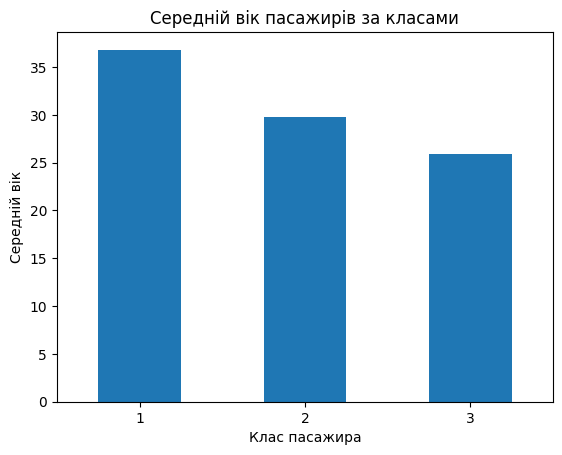

In [39]:
mean_age_by_class = df.groupby('Pclass')['Age'].mean()

mean_age_by_class.plot(kind='bar')

plt.xlabel('Клас пасажира')
plt.ylabel('Середній вік')
plt.title('Середній вік пасажирів за класами')
plt.xticks(rotation=0)
plt.show()

Середній вік пасажирів відрізняється залежно від класу. Найбільший середній вік спостерігається у 1 класі, а найменший — у 3 класі.


17.2 Обчисліть середній вік пасажирів для кожного класу (Pclass). Як вік пасажирів пов'язаний з виживанням (дати відповідь)?

In [42]:
survived_mean_age = df[df['Survived'] == 1]['Age'].mean()
not_survived_mean_age = df[df['Survived'] == 0]['Age'].mean()

print(f'Середній вік тих, хто вижив: {survived_mean_age:.2f}')
print(f'Середній вік тих, хто не вижив: {not_survived_mean_age:.2f}')

Середній вік тих, хто вижив: 28.29
Середній вік тих, хто не вижив: 30.03


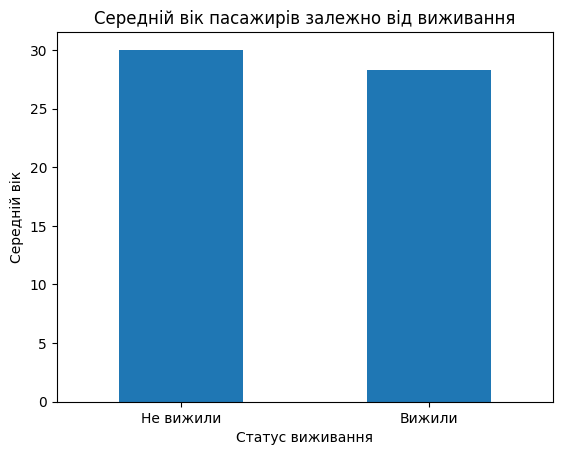

In [43]:
mean_age_survival = df.groupby('Survived')['Age'].mean()

mean_age_survival.index = ['Не вижили', 'Вижили']

mean_age_survival.plot(kind='bar')

plt.xlabel('Статус виживання')
plt.ylabel('Середній вік')
plt.title('Середній вік пасажирів залежно від виживання')
plt.xticks(rotation=0)
plt.show()

Різниця невелика, тому можна зробити висновок, що вік не мав значного впливу на виживання пасажирів.

In [50]:
# Clalculate survival rate per class per sex
for i in range(1, 4):
    for j in range(2):
        surv_rate = df[(df['Pclass'] == i) & (df['Sex'] == j) & (df['Survived'] == 1)].shape[0] / df[(df['Pclass'] == i) & (df['Sex'] == j)].shape[0]
        print(f'Share of survived {"male" if j == 0 else "female"} passengers in class {i}: {surv_rate * 100:.2f}%')

Share of survived male passengers in class 1: 36.89%
Share of survived female passengers in class 1: 96.81%
Share of survived male passengers in class 2: 15.74%
Share of survived female passengers in class 2: 92.11%
Share of survived male passengers in class 3: 13.54%
Share of survived female passengers in class 3: 50.00%


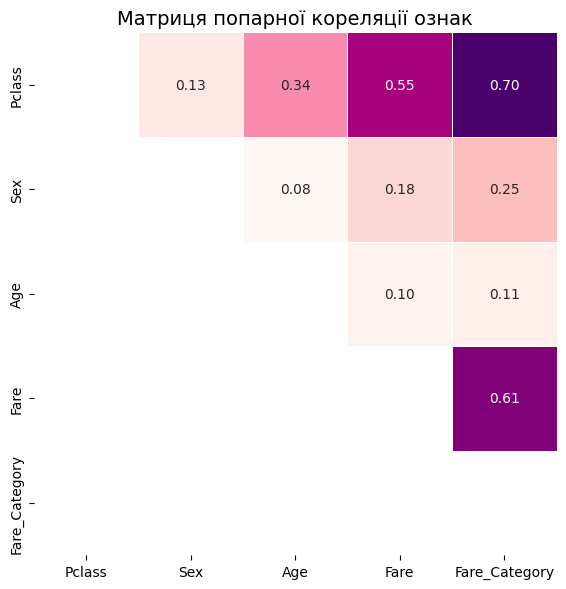

In [49]:
mtx = df.drop('Survived', axis=1).corr(numeric_only=True).abs()

# Побудова теплової карти кореляції
fig, ax = plt.subplots(figsize=(6, 6))

sns.heatmap(
    mtx,
    cmap='RdPu',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    mask=np.tril(np.ones_like(mtx, dtype=bool)),  # маскуємо нижній трикутник
    square=True,
    cbar=False,
    ax=ax
)

plt.title("Матриця попарної кореляції ознак", fontsize=14)
plt.tight_layout()
plt.show()

Найбільш помітна кореляція спостерігається між Fare та Pclass, тоді як між більшістю інших ознак зв’язок слабкий.

# **ЗАВДАННЯ 2**

Реалізувати 2 способи завантаження файлу (з комп'ютера та кагл)

1:

In [87]:
from google.colab import files

uploaded = files.upload()

Saving bestsellers.csv to bestsellers (1).csv


In [88]:
df = pd.read_csv('bestsellers.csv', encoding='latin1')
df

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
...,...,...,...,...,...,...,...
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8,2019,Fiction
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2016,Non Fiction
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2017,Non Fiction
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2018,Non Fiction


2:

In [89]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("sootersaalu/amazon-top-50-bestselling-books-2009-2019")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'amazon-top-50-bestselling-books-2009-2019' dataset.
Path to dataset files: /kaggle/input/amazon-top-50-bestselling-books-2009-2019


In [90]:
df = pd.read_csv(os.path.join(path, "bestsellers with categories.csv"))

df

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
...,...,...,...,...,...,...,...
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8,2019,Fiction
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2016,Non Fiction
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2017,Non Fiction
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2018,Non Fiction


**About Dataset**

The dataset contains information about the Top 50 bestselling books on Amazon from 2009 to 2019. It can be used to analyze book ratings, prices, reviews, authors, genres, and publication years.

**Name:** The title of the book.

**Author:** The author of the book.

**User Rating:** The average user rating of the book on Amazon, from 0 to 5.

**Reviews:** The number of user reviews the book received.

**Price:** The price of the book in US dollars.

**Year:** The year in which the book appeared in the bestseller ranking.

**Genre:** The genre of the book. There are two categories: Fiction and Non Fiction.

The main goal of using this dataset is to analyze Amazon's bestselling books, their ratings, prices, popularity, and distribution by genre and year. It can be used for data analysis and visualization.

In [91]:
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [92]:
df.shape

(550, 7)

In [93]:
df.duplicated().sum()

np.int64(0)

In [94]:
df.duplicated(subset='Name').sum()

np.int64(199)

In [95]:
df = df.drop_duplicates(subset='Name')

In [96]:
df.shape

(351, 7)

Про скільки книг зберігає дані датасет? Про 550, з яких 351 назва є унікальною.

Перейменувати стовпці
df.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']

In [97]:
df.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']
df.head()

,name,author,user_rating,reviews,price,year,genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 351 entries, 0 to 546
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         351 non-null    object 
 1   author       351 non-null    object 
 2   user_rating  351 non-null    float64
 3   reviews      351 non-null    int64  
 4   price        351 non-null    int64  
 5   year         351 non-null    int64  
 6   genre        351 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 21.9+ KB


Виведіть кількість пропусків (na) у кожному зі стовпців (використовуйте функції isna та sum)

In [99]:
df.isna().sum()

,0
name,0
author,0
user_rating,0
reviews,0
price,0
year,0
genre,0


Перевірте, які унікальні значення в колонці genre (використовуйте функцію unique)
Які є унікальні жанри?

In [100]:
df['genre'].value_counts()

,count
genre,
Non Fiction,191
Fiction,160


In [101]:
df['genre'].unique()

array(['Non Fiction', 'Fiction'], dtype=object)

У колонці genre є два унікальні значення: Non Fiction та Fiction.

Подивіться розподіл цін: побудуйте діаграму (використовуйте kind='hist')

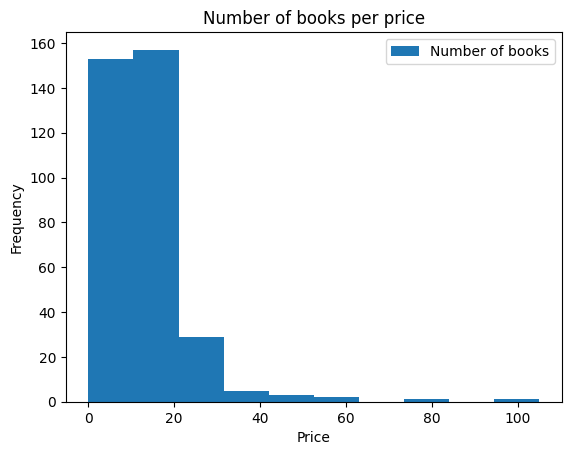

In [102]:
df['price'].plot(kind='hist', label='Number of books')
plt.xlabel('Price')
plt.title('Number of books per price')
plt.legend()
plt.show()

Визначте, яка ціна у нас максимальна, мінімальна, середня, медіанна (використовуйте функції max, min, mean, median)

In [103]:
df['price'].describe()

,price
count,351.000000
mean,13.076923
std,10.050860
min,0.000000
25%,8.000000
50%,12.000000
75%,16.000000
max,105.000000


In [104]:
# Визначаємо максимальну, мінімальну, середню та медіанну ціну книг
df['price'].agg(['max', 'min', 'mean', 'median'])

,price
max,105.000000
min,0.000000
mean,13.076923
median,12.000000


Який рейтинг у датасеті найвищий?

In [105]:
df['user_rating'].max()

4.9

Скільки книг мають такий рейтинг?

In [106]:
df[df['user_rating'] == 4.9]['name'].count()

np.int64(28)

У якої книги найбільше відгуків?

In [107]:
df[ df['reviews'] == df['reviews'].max() ]

,name,author,user_rating,reviews,price,year,genre
534,Where the Crawdads Sing,Delia Owens,4.8,87841,15,2019,Fiction


З тих книг, що потрапили до Топ-50 у 2015 році, яка книга найдорожча (можна використати проміжний датафрейм)?

In [108]:
max_price = df[df['year'] == 2015]['price'].max()
df[(df['year'] == 2015) & (df['price'] == max_price)]

,name,author,user_rating,reviews,price,year,genre
132,Go Set a Watchman: A Novel,Harper Lee,3.6,14982,19,2015,Fiction


Скільки книг жанру Fiction потрапили до Топ-50 у 2010 році (використовуйте &)?

In [109]:
df[(df['year'] == 2010) & (df['genre'] == 'Fiction')].count()['name']

np.int64(17)

Скільки книг з рейтингом 4.9 потрапило до рейтингу у 2010 та 2011 роках (використовуйте | або функцію isin)?

1 книга

In [110]:
df[ (df['user_rating'] == 4.9 ) & ((df['year']==2010) | (df['year'] == 2011)) ]

,name,author,user_rating,reviews,price,year,genre
187,Jesus Calling: Enjoying Peace in His Presence ...,Sarah Young,4.9,19576,8,2011,Non Fiction


Відсортуємо за зростанням ціни всі книги, які потрапили в рейтинг у 2015 році і коштують дешевше за 8 доларів (використовуйте функцію sort_values).

Яка книга остання у відсортованому списку?

In [111]:
df[(df['price'] < 8) & (df['year'] == 2015)].sort_values('price')

,name,author,user_rating,reviews,price,year,genre
54,Creative Haven Creative Cats Coloring Book (Ad...,Marjorie Sarnat,4.8,4022,4,2015,Non Fiction
123,Giraffes Can't Dance,Giles Andreae,4.8,14038,4,2015,Fiction
55,Creative Haven Owls Coloring Book (Adult Color...,Marjorie Sarnat,4.8,3871,5,2015,Non Fiction
28,Baby Touch and Feel: Animals,DK,4.6,5360,5,2015,Non Fiction
63,Dear Zoo: A Lift-the-Flap Book,Rod Campbell,4.8,10922,5,2015,Fiction
89,Dover Creative Haven Art Nouveau Animal Design...,Marty Noble,4.6,2134,5,2015,Non Fiction
201,Killing Reagan: The Violent Assault That Chang...,Bill O'Reilly,4.6,5235,5,2015,Non Fiction
16,Adult Coloring Book: Stress Relieving Animal D...,Blue Star Coloring,4.6,2925,6,2015,Non Fiction
17,Adult Coloring Book: Stress Relieving Patterns,Blue Star Coloring,4.4,2951,6,2015,Non Fiction
253,Old School (Diary of a Wimpy Kid #10),Jeff Kinney,4.8,6169,7,2015,Fiction


Остання книга:

In [112]:
df[(df['price'] < 8) & (df['year'] == 2015)].sort_values('price').tail(1)

,name,author,user_rating,reviews,price,year,genre
253,Old School (Diary of a Wimpy Kid #10),Jeff Kinney,4.8,6169,7,2015,Fiction


Вивести максимальну та мінімальну ціни для кожного з жанрів (використовуйте функції groupby та agg, для підрахунку мінімальних та максимальних значень використовуйте maxта min). Не беріть усі стовпці, виберете тільки потрібні вам

In [113]:
# Виводимо мінімальну та максимальну ціну книг для кожного жанру
df.groupby('genre')[['price']].agg(['min', 'max'])

price     
              min  max
genre                 
Fiction         0   82
Non Fiction     0  105

Кількість книг кожного автора

In [114]:
author_books = df.groupby(['author'])[['name']].count()
author_books

,name
author,
Abraham Verghese,1
Adam Gasiewski,1
Adam Mansbach,1
Adir Levy,1
Admiral William H. McRaven,1
...,...
Walter Isaacson,2
William Davis,1
William P. Young,1
